# MicroLive: Example for Multi-cell analysis

___
This notebook demonstrates how to use MicroLive programmatically for processing multi-cell microscopy datasets.

The used dataset is obtained from the following publication: <br>
Vo, H.D., et al., 2023. Analysis and design of single-cell experiments to harvest fluctuation information while rejecting measurement noise. Frontiers in Cell and Developmental Biology, 11, p.1133994. https://doi.org/10.3389/fcell.2023.1133994

----

This repository contains fluorescent images acquired with an Olympus IX81 inverted spinning disk confocal microscope with 60x/1.42 NA oil immersion objective. The link to the dataset is: https://zenodo.org/records/7868322

----

#### Imaging Conditions

**Cytosol Marker Experiments** (Objective: 60X)

| Laser (nm) | Power (mW) | Exposure (ms) |
|------------|------------|---------------|
| 405        | 20         | 100           |
| 488        | 20         | 100           |
| 561        | 20         | 100           |
| 640        | 30         | 300           |

**Channel Assignments:**
- **405 nm** — DAPI
- **488 nm** — MS2-MCP-GFP reporter
- **561 nm** — Cytosol marker
- **647 nm** — smiFISH MS2-Cy5

----

The microscope has a pixel size resolution in XY of 160 nm, a voxel-Z of 500 nm. 

Spot radius dimensions of 160 nm and 350 nm in the XY and Z planes, respectively.

-----

The selected image is a 3D dataset with 60 frames.

Dataset 0 : MS2-CY5_Cyto543_560_woStim <br>
ROI003_XY1657814110_Z00_T0_merged.tif

# Implementation Overview:

----
- Import libraries and configure paths
- Load microscopy images (TIFF or LIF)
- Cytosol and Nucleus segmentation (Cellpose)
- Spot detection (Big-FISH)
- Quantification of spots in nucleus and cytosol (MicroLive)

-----

### Load modules
----

In [ ]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage.measure import regionprops
import pandas as pd
from pathlib import Path
import tifffile
microlive_root = pathlib.Path().absolute().parents[1]
sys.path.append(str(microlive_root / 'src'))
import microscopy as mi
print(f"MicroLive loaded from: {microlive_root}")

MicroLive loaded from: /Users/nzlab-la/Desktop/microlive


In [ ]:
# Load the image
tif_image_path = Path("/Users/nzlab-la/Desktop/microlive/notebooks/examples/revision_data/Vo_2023/ROI003_XY1657814110_Z00_T0_merged.tif")
raw_image = tifffile.imread(str(tif_image_path))
print(f"Loaded TIFF with shape: {raw_image.shape}") # (Z, Y, X, C)

Loaded TIFF with shape: (27, 928, 624, 4)


In [ ]:
# Set the axis order that matches YOUR file
input_axis_order = ['Z', 'Y', 'X', 'C']  # Example: ZYXC format
# Convert to MicroLive's standard format [T, Z, Y, X, C]
converter = mi.ConvertFormat(
    image=raw_image,
    original_order=input_axis_order,
    desired_order=['T', 'Z', 'Y', 'X', 'C']
)
image_stack = converter.convert()
print(f"Converted to MicroLive format [T, Z, Y, X, C]: {image_stack.shape}") # the converted added a T dimension with a single time point.

Converted to MicroLive format [T, Z, Y, X, C]: (1, 27, 928, 624, 4)


### Define Image Metadata
-----

In [4]:
# Physical parameters (adjust to your microscope settings)
pixel_size_xy_nm = 160  # Pixel size in nanometers (XY)
voxel_size_z_nm = 500   # Voxel size in nanometers (Z)
time_interval_sec = 1.0  # Time between frames in seconds - This image contains a single timepoint.

# For MicroLive classes
list_voxels = [voxel_size_z_nm, pixel_size_xy_nm]  # [Z, YX]

# Extract dimensions from the correctly formatted image
n_timepoints = image_stack.shape[0]
n_zslices = image_stack.shape[1]
height_y = image_stack.shape[2]
width_x = image_stack.shape[3]
n_channels = image_stack.shape[4]

print(f"Image dimensions (TZYXC format):")
print(f"  Time points (T): {n_timepoints}")
print(f"  Z-slices (Z): {n_zslices}")
print(f"  Height (Y): {height_y} px")
print(f"  Width (X): {width_x} px")
print(f"  Channels (C): {n_channels}")
print(f"\nPhysical scale:")
print(f"  Pixel size: {pixel_size_xy_nm} nm")
print(f"  Z-step: {voxel_size_z_nm} nm")
print(f"  Frame interval: {time_interval_sec} sec")

Image dimensions (TZYXC format):
  Time points (T): 1
  Z-slices (Z): 27
  Height (Y): 928 px
  Width (X): 624 px
  Channels (C): 4

Physical scale:
  Pixel size: 160 nm
  Z-step: 500 nm
  Frame interval: 1.0 sec


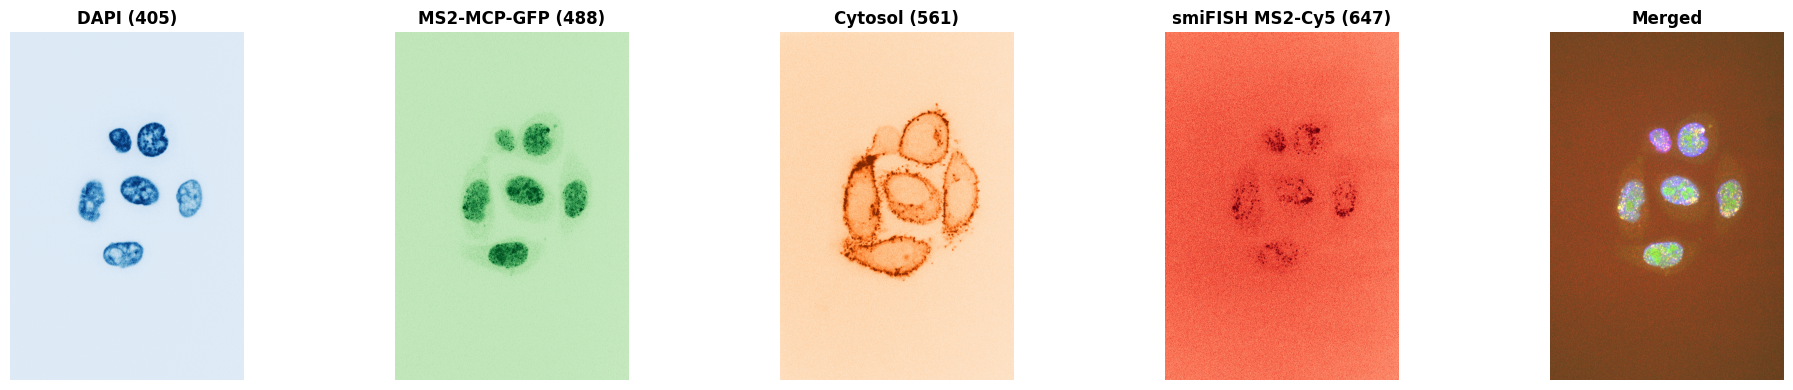

In [11]:
# Visualizing the image: all color channels for the first timepoint and the merged image
img_slice = image_stack[0, 14, :, :, :]  # Assuming image shape is [T, Z, Y, X, C]
# Channel names and colormaps
channel_names = ['DAPI (405)', 'MS2-MCP-GFP (488)', 'Cytosol (561)', 'smiFISH MS2-Cy5 (647)', 'Merged']
colormaps = ['Blues', 'Greens', 'Oranges', 'Reds', None]  # None for merged

vmax_values = [
    np.percentile(img_slice[:, :, 0], 99.5),  # Channel 0 (DAPI)
    np.percentile(img_slice[:, :, 1], 99.5),  # Channel 1 (GFP)
    np.percentile(img_slice[:, :, 2], 99.5),  # Channel 2 (Cytosol)
    np.percentile(img_slice[:, :, 3], 99.5),  # Channel 3 (Cy5)
]

# Create figure with 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot individual channels
for i in range(4):
    ax = axes[i]
    ax.imshow(img_slice[:, :, i], cmap=colormaps[i], vmin=0, vmax=vmax_values[i])
    ax.set_title(channel_names[i], fontsize=12, fontweight='bold')
    ax.axis('off')

# Create merged RGB image (select 3 channels for RGB)
# Adjust these indices based on which channels you want in R, G, B
merged = np.zeros((*img_slice.shape[:2], 3), dtype=np.float32)
merged[:, :, 0] = img_slice[:, :, 3] / vmax_values[3]  # Red = Cy5
merged[:, :, 1] = img_slice[:, :, 1] / vmax_values[1]  # Green = GFP
merged[:, :, 2] = img_slice[:, :, 0] / vmax_values[0]  # Blue = DAPI
merged = np.clip(merged, 0, 1)

axes[4].imshow(merged)
axes[4].set_title(channel_names[4], fontsize=12, fontweight='bold')
axes[4].axis('off')

plt.tight_layout()
plt.show()

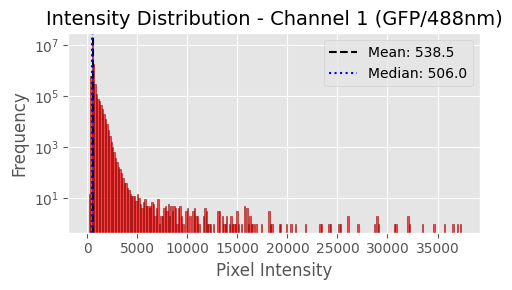

Min: 259, Max: 37361, Mean: 538.47


In [12]:
# Visualize the intensity distribution of the channel with spots
channel_1_data = image_stack[...,1].flatten()
# Create histogram
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(channel_1_data, bins=256, range=(0, channel_1_data.max()), 
        color='red', alpha=0.7, edgecolor='darkred', linewidth=0.5)
ax.set_xlabel('Pixel Intensity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Intensity Distribution - Channel 1 (GFP/488nm)', fontsize=14)
ax.set_yscale('log')  
ax.axvline(np.mean(channel_1_data), color='black', linestyle='--', label=f'Mean: {np.mean(channel_1_data):.1f}')
ax.axvline(np.median(channel_1_data), color='blue', linestyle=':', label=f'Median: {np.median(channel_1_data):.1f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Min: {channel_1_data.min()}, Max: {channel_1_data.max()}, Mean: {np.mean(channel_1_data):.2f}")

### Perform cytosol segmentation using cellpose
___

Running cytosol segmentation...
Model cyto3 loaded
Cytosol: 6 cells detected
Running nucleus segmentation...
Nucleus: 7 nuclei detected
After synchronization: 6 cells, 6 nuclei


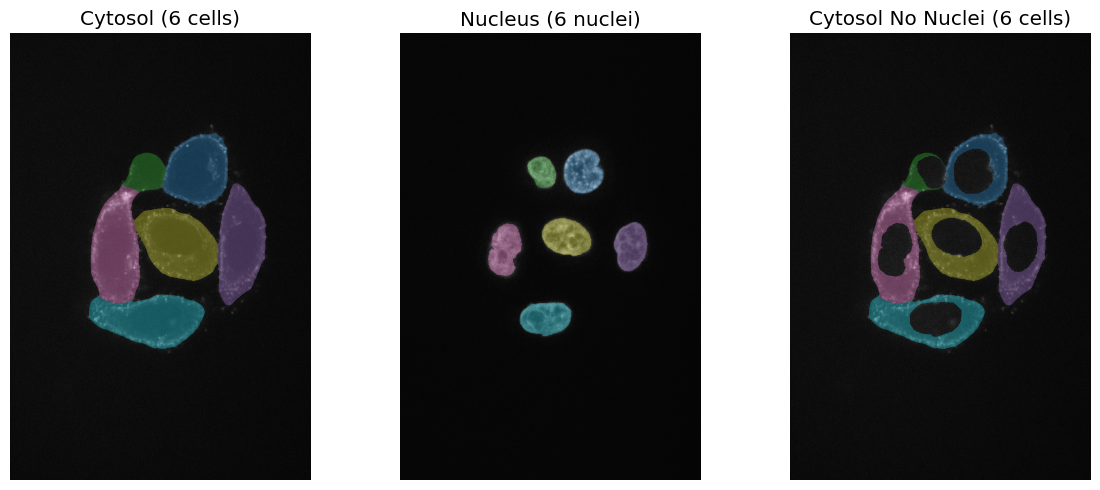

In [13]:
# Cellpose Segmentation - Matching GUI Behavior
# The GUI runs cytosol and nucleus segmentation as SEPARATE operations
# Channel and diameter settings
cytosol_channel = 2   # Channel index for cytosol segmentation
nucleus_channel = 0   # Channel index for nucleus segmentation (can be same or different)
diameter_cytosol = 120  # Average cytosol diameter in pixels
diameter_nucleus = 60   # Average nucleus diameter in pixels

# Cytosol Segmentation (using cyto3 model)
print("Running cytosol segmentation...")
segmenter_cyto = mi.CellSegmentation(
    img_slice,
    channels_cytosol=[cytosol_channel],
    channels_nucleus=None,  # Only cytosol
    diameter_cytosol=diameter_cytosol,
    model_cyto_segmentation='cyto3',  # Default model for cytosol
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
mask_cytosol, _, _ = segmenter_cyto.calculate_masks()
print(f"Cytosol: {np.max(mask_cytosol) if mask_cytosol is not None else 0} cells detected")

#  Nucleus Segmentation (using nuclei model)
print("Running nucleus segmentation...")
segmenter_nuc = mi.CellSegmentation(
    img_slice,
    channels_cytosol=None,  # Only nucleus
    channels_nucleus=[nucleus_channel],
    diameter_nucleus=diameter_nucleus,
    model_nuc_segmentation='nuclei',  # Default model for nucleus
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
_, mask_nucleus, _ = segmenter_nuc.calculate_masks()
print(f"Nucleus: {np.max(mask_nucleus) if mask_nucleus is not None else 0} nuclei detected")

#  Synchronize masks (ensures consistent cell IDs between cytosol and nucleus)
if mask_cytosol is not None and mask_nucleus is not None:
    mask_cytosol, mask_nucleus = mi.CellSegmentation.synchronize_masks(mask_cytosol, mask_nucleus)
    print(f"After synchronization: {np.max(mask_cytosol)} cells, {np.max(mask_nucleus)} nuclei")
# calculate mask cytosol no nuclei
masks_cytosol_no_nuclei = mask_cytosol.copy()
masks_cytosol_no_nuclei[mask_nucleus > 0] = 0

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
max_proj_cyto = img_slice[:, :, cytosol_channel]
max_proj_nuc = img_slice[:, :, nucleus_channel]
axes[0].imshow(max_proj_cyto, cmap='gray')
if mask_cytosol is not None and np.max(mask_cytosol) > 0:
    cytosol_overlay = np.ma.masked_where(mask_cytosol == 0, mask_cytosol)
    axes[0].imshow(cytosol_overlay, cmap='tab10', alpha=0.4)
axes[0].set_title(f'Cytosol ({np.max(mask_cytosol) if mask_cytosol is not None else 0} cells)')
axes[0].axis('off')
axes[1].imshow(max_proj_nuc, cmap='gray')
if mask_nucleus is not None and np.max(mask_nucleus) > 0:
    nucleus_overlay = np.ma.masked_where(mask_nucleus == 0, mask_nucleus)
    axes[1].imshow(nucleus_overlay, cmap='tab10', alpha=0.4)
axes[1].set_title(f'Nucleus ({np.max(mask_nucleus) if mask_nucleus is not None else 0} nuclei)')
axes[1].axis('off')
axes[2].imshow(max_proj_cyto, cmap='gray')
if masks_cytosol_no_nuclei is not None and np.max(masks_cytosol_no_nuclei) > 0:
    cytosol_no_nuclei_overlay = np.ma.masked_where(masks_cytosol_no_nuclei == 0, masks_cytosol_no_nuclei)
    axes[2].imshow(cytosol_no_nuclei_overlay, cmap='tab10', alpha=0.4)
axes[2].set_title(f'Cytosol No Nuclei ({np.max(masks_cytosol_no_nuclei) if masks_cytosol_no_nuclei is not None else 0} cells)')
axes[2].axis('off')
plt.tight_layout()
plt.show()


### 3D Spot Detection with Pre-computed Masks
____

In [14]:
# Voxel sizes in nm: [voxel_z, voxel_yx]
list_voxels = [500, 160]

# Spot detection parameters
channel_for_spots = 1       # Channel to detect spots in
threshold = 120  

yx_spot_size_px = 5         # Expected spot diameter in XY (pixels)
z_spot_size_px = 3          # Spot size in Z (pixels)
cluster_radius_nm = 500     # Cluster detection radius

# Run spot detection with pre-computed masks
spot_detector = mi.SpotDetection(
    image=image_stack[0],                           # [Z, Y, X, C]
    channels_spots=[channel_for_spots],          # Which channel(s) to detect spots
    channels_cytosol=0,                       # Not needed - using pre-computed mask
    channels_nucleus=0,                       # Not needed - using pre-computed mask
    masks_complete_cells=mask_cytosol,           # Pre-computed cytosol mask [Y, X]
    masks_nuclei=mask_nucleus,                   # Pre-computed nucleus mask [Y, X]
    masks_cytosol_no_nuclei=masks_cytosol_no_nuclei,                # Will be computed internally if needed
    list_voxels=list_voxels,
    yx_spot_size_in_px=yx_spot_size_px,
    z_spot_size_in_px=z_spot_size_px,
    cluster_radius_nm=cluster_radius_nm,
    threshold_for_spot_detection=[threshold],
    show_plot=True,
    save_files=False,
    use_maximum_projection=False,
)
# Get detection results
df_spots = spot_detector.get_dataframe()[0]
display(df_spots.head())

,image_id,cell_id,spot_id,nuc_loc_y,nuc_loc_x,cyto_loc_y,cyto_loc_x,nuc_area_px,cyto_area_px,cell_area_px,...,snr_ch_2,snr_ch_3,total_spot_int_ch_0,total_spot_int_ch_1,total_spot_int_ch_2,total_spot_int_ch_3,spot_size_ch_0,spot_size_ch_1,spot_size_ch_2,spot_size_ch_3
0,0,0,0,287,379,284,389,6020,9972,16080,...,0.1097,2.6999,70153.0,50561.0,39215.0,37980.0,3.1340,2.9077,3.5042,2.8213
1,0,0,1,287,379,284,389,6020,9972,16080,...,-0.2016,1.5588,56530.0,58458.0,32912.0,57154.0,3.2424,2.8649,3.2883,2.9353
2,0,0,2,287,379,284,389,6020,9972,16080,...,0.0268,7.6233,96718.0,381102.0,36370.0,487470.0,3.3104,2.6308,3.3358,2.5458
3,0,0,3,287,379,284,389,6020,9972,16080,...,-0.3215,0.1737,63227.0,39880.0,31677.0,32940.0,3.3535,3.0620,3.4025,3.1924
4,0,0,4,287,379,284,389,6020,9972,16080,...,0.4451,0.9185,63815.0,59640.0,32103.0,37396.0,3.4800,3.0554,3.3641,3.0636


Visualizing Maximum Intensity Projection (MIP)


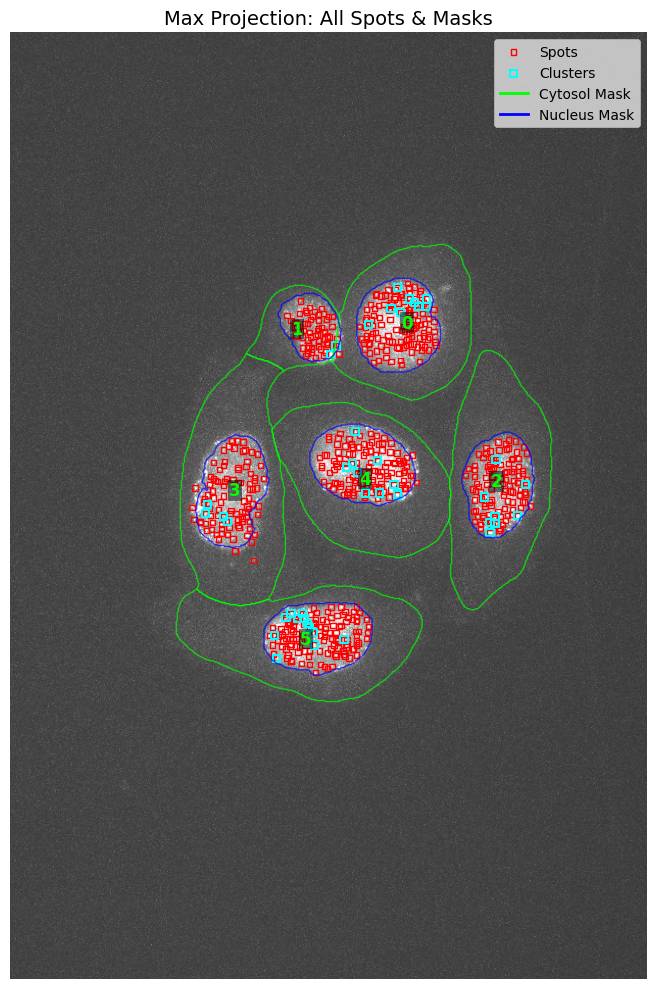

In [15]:
# --- Visualization Parameters ---
z_slice_index = 10       # Index of Z-slice to view (set to None for Max Projection)
use_max_projection = True # Set to True to show Max Projection
marker_size = 15         # Size of the square markers
label_cells = True       # Whether to label cell IDs

if use_max_projection or z_slice_index is None:
    # Max projection
    print("Visualizing Maximum Intensity Projection (MIP)")
    img_slice = np.max(image_stack[0, :, :, :, channel_for_spots], axis=0) # [Y, X]
    spots_to_plot = df_spots
    plot_title = "Max Projection: All Spots & Masks"
else:
    # Single Z-slice
    print(f"Visualizing Z-Slice: {z_slice_index}")
    img_slice = image_stack[0, z_slice_index, :, :, channel_for_spots]
    spots_to_plot = df_spots[df_spots['z'] == z_slice_index]
    plot_title = f"Z-Slice {z_slice_index}: Spots & Masks"
# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))
vmax = np.percentile(img_slice, 99.5)
ax.imshow(img_slice, cmap='gray', origin='upper', vmin=0, vmax=vmax)
# Plot Spots
if not spots_to_plot.empty:
    ax.scatter(spots_to_plot['x'], spots_to_plot['y'], s=marker_size, 
               c='none', edgecolors='red', marker='s', linewidth=1, label='Spots')
# Plot Clusters
if 'is_cluster' in spots_to_plot.columns:
    clusters = spots_to_plot[spots_to_plot['is_cluster'] == 1]
    if not clusters.empty:
        ax.scatter(clusters['x'], clusters['y'], s=marker_size*1.8, 
                   c='none', edgecolors='cyan', marker='s', linewidth=1.5, label='Clusters')
# Plot Masks (Per-Cell Contours)
unique_cells = np.unique(mask_cytosol)
unique_cells = unique_cells[unique_cells > 0] # Exclude background
for cell_id in unique_cells:
    ax.contour(mask_cytosol == cell_id, levels=[0.5], colors='lime', linewidths=1, alpha=0.7)
    if np.any(mask_nucleus == cell_id):
        ax.contour(mask_nucleus == cell_id, levels=[0.5], colors='blue', linewidths=1, alpha=0.7)
if label_cells:
    props = regionprops(mask_cytosol)
    for prop in props:
        y, x = prop.centroid
        ax.text(x, y, str(prop.label-1), color='lime', fontsize=12, fontweight='bold', 
                ha='center', va='center', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))
custom_lines = [Line2D([0], [0], color='lime', lw=2),
                Line2D([0], [0], color='blue', lw=2)]
handles, labels_legend = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels_legend.extend(['Cytosol Mask', 'Nucleus Mask'])
ax.set_title(plot_title, fontsize=14)
ax.legend(handles, labels_legend, loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

### Reporting the number of spots detected for each cell.


In [16]:
# Create Summary Table
summary_data = []
unique_cell_ids = df_spots['cell_id'].unique()
unique_cell_ids = [cid for cid in unique_cell_ids if cid != -1]
for cell_id in unique_cell_ids:
    cell_spots = df_spots[df_spots['cell_id'] == cell_id]
    if 'is_cluster' in cell_spots.columns:
        n_clusters_nuc = len(cell_spots[(cell_spots['is_nuc'] == 1) & (cell_spots['is_cluster'] == 1)])
        n_clusters_cyto = len(cell_spots[(cell_spots['is_nuc'] == 0) & (cell_spots['is_cluster'] == 1)])
    else:
        n_clusters_nuc = 0
        n_clusters_cyto = 0
    if 'is_cluster' in cell_spots.columns:
        n_spots_nuc = len(cell_spots[(cell_spots['is_nuc'] == 1) & (cell_spots['is_cluster'] == 0)])
        n_spots_cyto = len(cell_spots[(cell_spots['is_nuc'] == 0) & (cell_spots['is_cluster'] == 0)])
    else:
        n_spots_nuc = len(cell_spots[cell_spots['is_nuc'] == 1])
        n_spots_cyto = len(cell_spots[cell_spots['is_nuc'] == 0])
    summary_data.append({
        'cell_id': int(cell_id),
        'spots_in_nuc': n_spots_nuc,
        'spots_in_cyto': n_spots_cyto,
        'clusters_in_nuc': n_clusters_nuc,
        'clusters_in_cyto': n_clusters_cyto
    })
df_summary = pd.DataFrame(summary_data)
padding = {
    'cell_id': 0, 'spots_in_nuc': 0, 'spots_in_cyto': 0, 
    'clusters_in_nuc': 0, 'clusters_in_cyto': 0
} 
print("Summary Statistics per Cell:")
display(df_summary) 

Summary Statistics per Cell:


,cell_id,spots_in_nuc,spots_in_cyto,clusters_in_nuc,clusters_in_cyto
0,0,117,2,9,0
1,1,62,0,2,0
2,2,105,1,8,0
3,3,84,9,4,0
4,4,116,2,10,0
5,5,120,0,12,0
